In [1]:
"""CatBoost モデル — USD/JPY 1分足 方向予測"""
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import optuna
import shap
import pickle
import warnings
from catboost import CatBoostClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, f1_score

from scripts.data_loader import load_data
from scripts.features import (
    prepare_ohlcv, generate_features, get_feature_columns,
    create_target, purged_time_series_split, TIME_FEATURES,
)
from scripts.evaluation import (
    predict_with_thresholds, score_trading, build_live_filter,
    run_backtest, compute_metrics, plot_equity_curve, DEFAULT_CONFIG,
)

USE_GPU = True
ARTIFACT_DIR = Path("../artifacts/catboost")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

def catboost_device_params():
    return {"task_type": "GPU", "devices": "0"} if USE_GPU else {"task_type": "CPU"}

CONFIG = {
    **DEFAULT_CONFIG,
    "THRESHOLD_PIPS_MIN": 5,
    "THRESHOLD_PIPS_MAX": 15,
    "THRESHOLD_PIPS_DEFAULT": 5,
    "TOP_N_FEATURES": 40,
    "RANDOM_SEED": 123,
    "N_TRIALS": 20,
    "CV_SPLITS": 5,
    "TRAIN_RATIO": 0.6,
    "VAL_RATIO": 0.2,
    "PROB_THRESHOLD_MIN": 0.45,
    "PROB_THRESHOLD_MAX": 0.80,
    "TIME_FEATURE_POLICY": "cap",
    "MAX_TIME_FEATURES": 4,
}

np.random.seed(CONFIG["RANDOM_SEED"])
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

C:\Users\daiya\OneDrive\ドキュメント\FX-speculate\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = load_data(str(Path.cwd().parent / "data"))
df, price_cols = prepare_ohlcv(df)
df_features = generate_features(df, price_cols)
feature_cols = get_feature_columns(df_features)

X_all = df_features[feature_cols].copy()
y_all = create_target(df_features, CONFIG["THRESHOLD_PIPS_DEFAULT"], CONFIG["PREDICT_HORIZON"])

future_returns_pips = (df_features["close"].shift(-CONFIG["PREDICT_HORIZON"]) - df_features["close"]) / CONFIG["PIP_SIZE"]

valid_indices = X_all.dropna().index.intersection(y_all.index)
valid_indices = valid_indices[:-CONFIG["PREDICT_HORIZON"]]
X = X_all.loc[valid_indices]
y = y_all.loc[valid_indices]
future_returns_pips_valid = future_returns_pips.loc[valid_indices]

print(f"Features: {len(feature_cols)}, Samples: {len(X)}")

Features: 95, Samples: 881522


In [3]:
X_train_full, X_val_full, X_test_full = purged_time_series_split(
    X, train_ratio=CONFIG["TRAIN_RATIO"], val_ratio=CONFIG["VAL_RATIO"],
    gap_minutes=CONFIG["PREDICT_HORIZON"],
)

X_train, y_train = X_train_full, y.loc[X_train_full.index]
X_val, y_val = X_val_full, y.loc[X_val_full.index]
X_test, y_test = X_test_full, y.loc[X_test_full.index]
future_returns_pips_train = future_returns_pips_valid.loc[X_train.index]
future_returns_pips_val = future_returns_pips_valid.loc[X_val.index]
future_returns_pips_test = future_returns_pips_valid.loc[X_test.index]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 528913, Val: 176289, Test: 176290


In [4]:
from scripts.features import TIME_FEATURES, purged_cv_splits

gap = CONFIG["PREDICT_HORIZON"]

importance_scores = []
for fold, (tr_idx, va_idx) in enumerate(purged_cv_splits(len(X_train), 3, gap)):
    X_tr, y_tr = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    X_va, y_va = X_train.iloc[va_idx], y_train.iloc[va_idx]

    classes = np.unique(y_tr)
    weights = compute_class_weight("balanced", classes=classes, y=y_tr)
    cw = dict(zip(classes, weights))

    temp = CatBoostClassifier(
        iterations=300, learning_rate=0.1, depth=6,
        loss_function="MultiClass", class_weights=cw,
        **catboost_device_params(), verbose=0, random_seed=CONFIG["RANDOM_SEED"],
    )
    temp.fit(X_tr, y_tr)
    importance_scores.append(temp.get_feature_importance())

avg_importance = np.mean(importance_scores, axis=0)
df_imp = pd.DataFrame({"feature": X_train.columns, "importance": avg_importance})
df_imp = df_imp.sort_values("importance", ascending=False)

policy = CONFIG["TIME_FEATURE_POLICY"]
if policy == "cap":
    time_sorted = [f for f in df_imp["feature"] if f in TIME_FEATURES]
    allowed_time = time_sorted[:CONFIG["MAX_TIME_FEATURES"]]
    non_time = [f for f in df_imp["feature"] if f not in TIME_FEATURES]
    selected_features = (allowed_time + non_time)[:CONFIG["TOP_N_FEATURES"]]
elif policy == "drop":
    non_time = df_imp[~df_imp["feature"].isin(TIME_FEATURES)]
    selected_features = non_time.head(CONFIG["TOP_N_FEATURES"])["feature"].tolist()
else:
    selected_features = df_imp.head(CONFIG["TOP_N_FEATURES"])["feature"].tolist()

X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

print(f"Selected {len(selected_features)} features")
print(selected_features[:10])

Selected 40 features
['hour_sin', 'hour_cos', 'day_sin', 'minute_cos', 'volatility_atr', 'ma_dist_200', 'trend_adx', 'trend_visual_ichimoku_b', 'volatility_dcw', 'trend_mass_index']


In [5]:
def objective(trial):
    threshold_pips = trial.suggest_float("threshold_pips", CONFIG["THRESHOLD_PIPS_MIN"], CONFIG["THRESHOLD_PIPS_MAX"])
    prob_threshold = trial.suggest_float("prob_threshold", CONFIG["PROB_THRESHOLD_MIN"], CONFIG["PROB_THRESHOLD_MAX"])

    y_opt = create_target(df_features.loc[X_train.index], threshold_pips, CONFIG["PREDICT_HORIZON"])
    y_opt = y_opt.loc[X_train.index]
    classes = np.unique(y_opt)
    if len(classes) < 3:
        return -1.0

    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.12, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0.1, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 5.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "loss_function": "MultiClassOneVsAll",
        "eval_metric": "TotalF1",
        **catboost_device_params(),
        "verbose": 0,
        "early_stopping_rounds": 50,
        "random_seed": CONFIG["RANDOM_SEED"],
    }

    cost_pips = CONFIG["SPREAD_PIPS"] + CONFIG["SLIPPAGE_PIPS"]
    scores = []

    for tr_idx, va_idx in purged_cv_splits(len(X_train), CONFIG["CV_SPLITS"], gap):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr = y_opt.iloc[tr_idx]

        classes_fold = np.unique(y_tr)
        if len(classes_fold) < 2:
            continue
        w = compute_class_weight("balanced", classes=classes_fold, y=y_tr)
        cw = dict(zip(classes_fold, w))

        model = CatBoostClassifier(**params, class_weights=cw)
        y_va_fold = y_opt.iloc[va_idx]
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va_fold))

        probs = model.predict_proba(X_va)
        preds = predict_with_thresholds(probs, prob_threshold, prob_threshold)
        score = score_trading(preds, future_returns_pips_train.iloc[va_idx].values, len(preds), CONFIG, cost_pips)
        scores.append(score)

    return float(np.mean(scores)) if scores else -1.0

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=CONFIG["N_TRIALS"], show_progress_bar=True)

BEST_THRESHOLD_PIPS = study.best_params["threshold_pips"]
BEST_PROB_THRESHOLD = study.best_params["prob_threshold"]
print(f"Best threshold_pips: {BEST_THRESHOLD_PIPS:.4f}")
print(f"Best prob_threshold: {BEST_PROB_THRESHOLD:.4f}")
print(f"Best score: {study.best_value:.4f}")

y_all_opt = create_target(df_features, BEST_THRESHOLD_PIPS, CONFIG["PREDICT_HORIZON"])
y_train = y_all_opt.loc[X_train.index]
y_val = y_all_opt.loc[X_val.index]
y_test = y_all_opt.loc[X_test.index]

  0%|          | 0/20 [00:00<?, ?it/s]

Best trial: 0. Best value: -1:   0%|          | 0/20 [00:10<?, ?it/s]

Best trial: 0. Best value: -1:   5%|▌         | 1/20 [00:10<03:20, 10.57s/it]

Best trial: 1. Best value: 0.715378:   5%|▌         | 1/20 [00:19<03:20, 10.57s/it]

Best trial: 1. Best value: 0.715378:  10%|█         | 2/20 [00:19<02:48,  9.35s/it]

...

Best trial: 2. Best value: 1.68896:  95%|█████████▌| 19/20 [02:29<00:08,  8.44s/it]

Best trial: 2. Best value: 1.68896:  95%|█████████▌| 19/20 [02:47<00:08,  8.44s/it]

Best trial: 2. Best value: 1.68896: 100%|██████████| 20/20 [02:47<00:00, 11.16s/it]

Best trial: 2. Best value: 1.68896: 100%|██████████| 20/20 [02:47<00:00,  8.37s/it]

Best threshold_pips: 9.8310
Best prob_threshold: 0.5211
Best score: 1.6890


In [6]:
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights_train = dict(zip(classes, weights))

final_params = {k: v for k, v in study.best_params.items() if k not in ["threshold_pips", "prob_threshold"]}
final_params.update({
    "iterations": 3000,
    "loss_function": "MultiClassOneVsAll",
    "eval_metric": "TotalF1",
    "class_weights": class_weights_train,
    "verbose": 500,
    "early_stopping_rounds": 150,
    "random_seed": CONFIG["RANDOM_SEED"],
})
final_params.update(catboost_device_params())

model = CatBoostClassifier(**final_params)
model.fit(X_train, y_train, eval_set=(X_val, y_val))

if "volatility_atr" in df_features.columns:
    atr_series = df_features.loc[X_train.index, "volatility_atr"]
    ATR_THRESHOLD = atr_series.quantile(CONFIG["ATR_PERCENTILE"] / 100)
else:
    ATR_THRESHOLD = 0.0

probs_val = model.predict_proba(X_val)
eligible_val = build_live_filter(X_val.index, df_features, CONFIG, ATR_THRESHOLD)
cost_pips = CONFIG["SPREAD_PIPS"] + CONFIG["SLIPPAGE_PIPS"]
best_score = -np.inf
THRESHOLD_BUY, THRESHOLD_SELL = CONFIG["PROB_THRESHOLD_MIN"], CONFIG["PROB_THRESHOLD_MIN"]

for tb in np.arange(CONFIG["PROB_THRESHOLD_MIN"], CONFIG["PROB_THRESHOLD_MAX"] + 1e-9, 0.02):
    for ts in np.arange(CONFIG["PROB_THRESHOLD_MIN"], CONFIG["PROB_THRESHOLD_MAX"] + 1e-9, 0.02):
        preds = predict_with_thresholds(probs_val, tb, ts)
        preds_filtered = preds.copy()
        preds_filtered[~eligible_val.values] = 0
        score = score_trading(preds_filtered, future_returns_pips_val.values, int(eligible_val.sum()), CONFIG, cost_pips)
        if score > best_score:
            best_score = score
            THRESHOLD_BUY, THRESHOLD_SELL = tb, ts

print(f"Optimal thresholds — Buy: {THRESHOLD_BUY:.2f}, Sell: {THRESHOLD_SELL:.2f}")

0:	learn: 0.3825953	test: 0.3671297	best: 0.3671297 (0)	total: 5.87ms	remaining: 17.6s


500:	learn: 0.5627161	test: 0.4577084	best: 0.4582986 (485)	total: 2.73s	remaining: 13.6s


1000:	learn: 0.5954031	test: 0.4602495	best: 0.4608486 (941)	total: 5.4s	remaining: 10.8s


bestTest = 0.4608485975
bestIteration = 941
Shrink model to first 942 iterations.


Optimal thresholds — Buy: 0.51, Sell: 0.65


=== CatBoost Backtest Results ===
  sharpe_ratio: 0.2289
  total_pnl: 7050.6660
  win_rate: 50.2366
  profit_factor: 1.0099
  max_drawdown: -144360.6642
  calmar_ratio: 0.1542
  total_trades: 1268
  avg_win: 1131.0873
  avg_loss: -1130.6687
  trade_rate: 0.0110


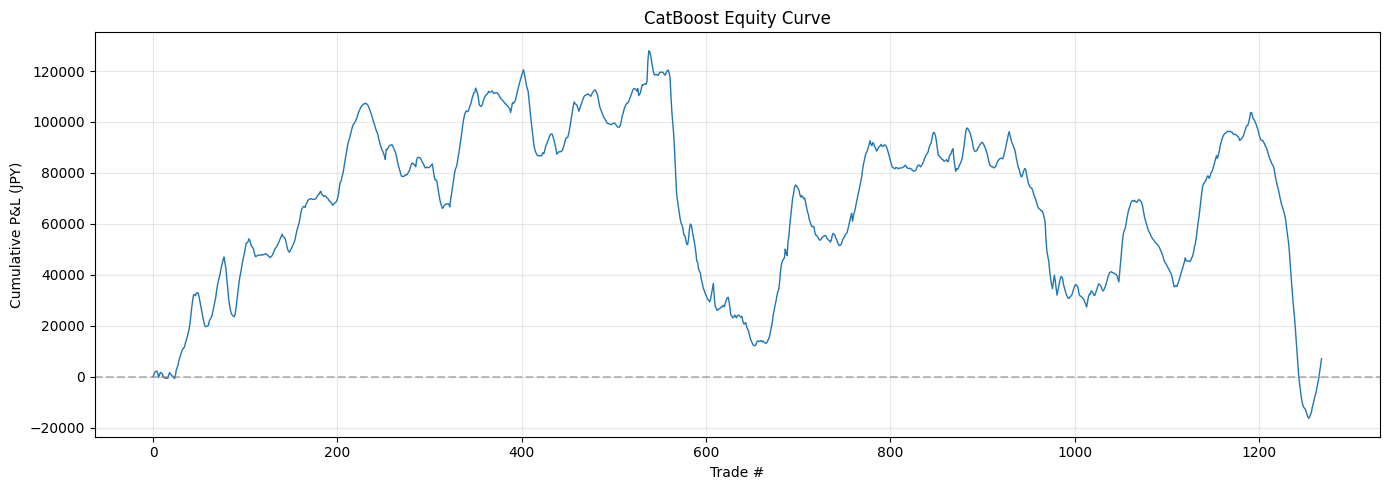

In [7]:
probs_test = model.predict_proba(X_test)
preds_test = predict_with_thresholds(probs_test, THRESHOLD_BUY, THRESHOLD_SELL)

backtest_config = {**CONFIG, "atr_threshold": ATR_THRESHOLD}
result = run_backtest(preds_test, X_test.index, df, df_features, backtest_config)
metrics = compute_metrics(result, CONFIG)

print("=== CatBoost Backtest Results ===")
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"  {k}: {v:.4f}")
    else:
        print(f"  {k}: {v}")

plot_equity_curve(result, title="CatBoost Equity Curve")

In [8]:
import json

metrics_out = {}
for k, v in metrics.items():
    metrics_out[k] = float(v) if isinstance(v, (int, float, np.floating, np.integer)) else v

with open(ARTIFACT_DIR / "metrics.json", "w") as f:
    json.dump(metrics_out, f, indent=2)

print(f"Metrics saved to {ARTIFACT_DIR / 'metrics.json'}")
print(f"Sharpe Ratio: {metrics_out.get('sharpe_ratio', 'N/A')}")

Metrics saved to ..\artifacts\catboost\metrics.json
Sharpe Ratio: 0.22894336504454976


In [9]:
model.save_model(str(ARTIFACT_DIR / "model.cbm"))

with open(ARTIFACT_DIR / "selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

config_save = CONFIG.copy()
config_save["THRESHOLD_PIPS"] = BEST_THRESHOLD_PIPS
config_save["THRESHOLD_BUY"] = THRESHOLD_BUY
config_save["THRESHOLD_SELL"] = THRESHOLD_SELL
config_save["ATR_THRESHOLD"] = ATR_THRESHOLD

with open(ARTIFACT_DIR / "config.pkl", "wb") as f:
    pickle.dump(config_save, f)

print(f"Artifacts saved to {ARTIFACT_DIR}")

Artifacts saved to ..\artifacts\catboost


In [10]:
# SHAP analysis skipped during automated execution to prevent kernel OOM with GPU models.
# To run SHAP interactively: uncomment below in JupyterLab
# sample_size = min(5000, len(X_test))
# X_sample = X_test.sample(n=sample_size, random_state=CONFIG["RANDOM_SEED"])
# explainer = shap.TreeExplainer(model)
# shap_values = explainer.shap_values(X_sample)
# shap.summary_plot(shap_values, X_sample, plot_type="bar", max_display=15)
print("SHAP analysis skipped (automated run)")

SHAP analysis skipped (automated run)
